# Trend's Not Dead

https://www.cmegroup.com/content/dam/cmegroup/education/files/trends-not-dead-babbedge-kerson-2019.pdf

# Packages

In [1]:
import os
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [39]:
blog_path = os.getcwd()
res_path  = os.path.abspath(os.path.join(blog_path, ".."))
repo_path = os.path.abspath(os.path.join(res_path, ".."))
data_path = os.path.join(repo_path, "data")

In [42]:
path = os.path.join(data_path, "TrendIndices", "TrendIndicesGuide.xlsx")
df_ticker = (pd
    .read_excel(
        io         = path, 
        sheet_name = "TrendIndices")
    .rename(columns = {
        "Ticker"     : "ticker",
        "Asset Class": "asset_class"}))

In [44]:
path = os.path.join(data_path, "TrendIndices", "RawTrendIndices.parquet")
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .rename(columns = {"security": "ticker"}))

In [4]:
def _get_desc_stat(df: pd.DataFrame) -> pd.DataFrame: 

    sharpe = (df
        [["rtn"]]
        .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
        .item())

    df_out = (df
        [["date"]]
        .agg(["min", "max"])
        .T
        .assign(sharpe = sharpe))

    return df_out

gfc_date = dt.date(year = 2009, month = 3, day = 1)

df_prep = (df_raw
    .set_index("date")
    .groupby("ticker")
    .apply(lambda x: x.sort_index().pct_change())
    .rename(columns = {"PX_LAST": "rtn"})
    .reset_index()
    .assign(
        date       = lambda x: pd.to_datetime(x.date).dt.date,
        date_group = lambda x: np.where(x.date <= gfc_date, "before_gfc", "after_gfc"),
        group_var  = lambda x: x.date_group + "-" + x.ticker))

df_stat = (df_prep
    .groupby("group_var")
    .apply(_get_desc_stat)
    .reset_index()
    .drop(columns = ["level_1"])
    .rename(columns = {
        "min": "start_date",
        "max": "end_date"})
    .assign(
        date_group = lambda x: x.group_var.str.split("-").str[0],
        ticker     = lambda x: x.group_var.str.split("-").str[1])
    .drop(columns = ["group_var"]))

In [5]:
df_sharpe = (df_stat
    .assign(
        start_date = lambda x: pd.to_datetime(x.start_date),
        end_date   = lambda x: pd.to_datetime(x.end_date),
        years      = lambda x: (x.end_date - x.start_date).dt.days / 360)
    .drop(columns = ["start_date", "end_date"])
    .melt(id_vars = ["date_group", "ticker"])
    .assign(name = lambda x: x.date_group + "_" + x.variable)
    .pivot(index = "ticker", columns = "name", values = "value")
    .dropna())

In [6]:
sharpe_ols = (sm
    .OLS(
        endog = df_sharpe.after_gfc_sharpe,
        exog  = sm.add_constant(df_sharpe.before_gfc_sharpe))
    .fit())

In [7]:
param_dict = sharpe_ols.params.to_dict()

In [8]:
x = (np
    .linspace(
        start = df_sharpe.before_gfc_sharpe.min(),
        stop  = df_sharpe.before_gfc_sharpe.max(),
        num   = 1_000))

y = (x * param_dict["before_gfc_sharpe"]) + param_dict["const"]

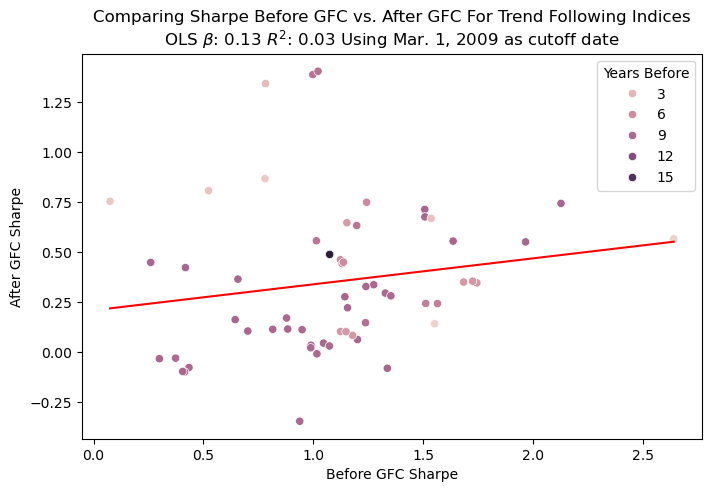

In [9]:
df_plot = (df_sharpe
    .rename(columns = {"before_gfc_years": "Years Before"}))

fig, axes = plt.subplots(figsize = (8,5))

(sns
    .scatterplot(
        ax   = axes,
        data = df_plot,
        x    = "before_gfc_sharpe",
        y    = "after_gfc_sharpe",
        hue  = "Years Before"))

axes.plot(
    x,
    y,
    color = "red")

axes.set_xlabel("Before GFC Sharpe")
axes.set_ylabel("After GFC Sharpe")
axes.set_title(
    "Comparing Sharpe Before GFC vs. After GFC For Trend Following Indices\n" +  r"OLS $\beta$: {} $R^2$: {} Using Mar. 1, 2009 as cutoff date"
    .format(np.round(param_dict["before_gfc_sharpe"], 2), np.round(sharpe_ols.rsquared, 2)))

plt.show()

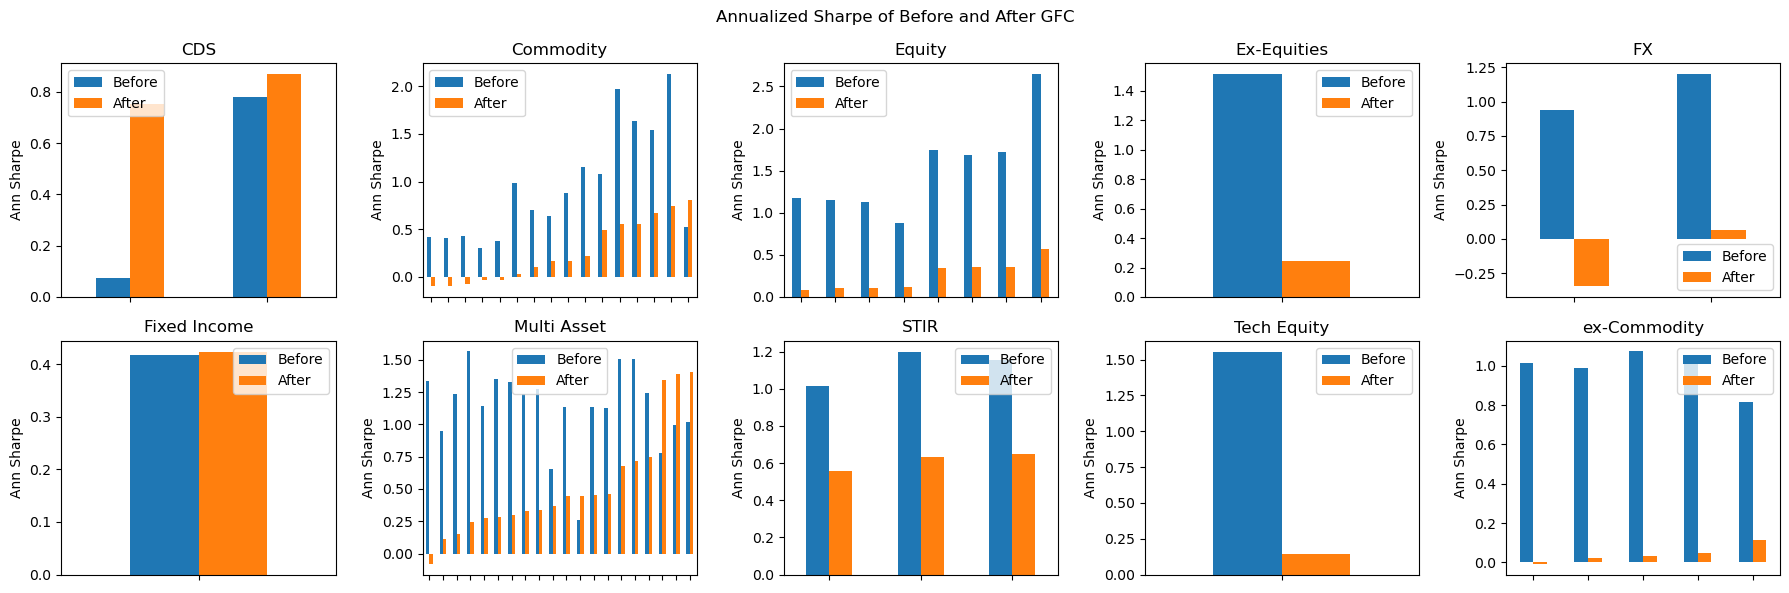

In [10]:
df_compare_prep = (df_sharpe
    .reset_index()
    .merge(right = df_ticker, how = "inner", on = ["ticker"]))

asset_classes = df_compare_prep.asset_class.drop_duplicates().sort_values().to_list()
fig, axes     = plt.subplots(ncols = len(asset_classes) // 2, nrows = 2, figsize = (18,6))

for asset_class, ax in zip(asset_classes, axes.flatten()): 

    (df_compare_prep
        .loc[lambda x: x.asset_class == asset_class]
        .assign(PlotName = "")
        .set_index("PlotName")
        [["before_gfc_sharpe", "after_gfc_sharpe"]]
        .sort_values("after_gfc_sharpe")
        .rename(columns = {
            "before_gfc_sharpe": "Before",
            "after_gfc_sharpe" : "After"})
        .plot(
            ax     = ax,
            kind   = "bar",
            xlabel = "",
            ylabel = "Ann Sharpe",
            title  = asset_class))

fig.suptitle("Annualized Sharpe of Before and After GFC")
plt.tight_layout()

In [11]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\Signals\DaoNguyenDerembleLemperiereBouchaudPotters.parquet"
path = os.path.join(data_path, "Signals",)
df_signal = (pd.read_parquet(path = path, engine = "pyarrow"))

In [12]:
path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\TrendIndices\TrendIndicesGuide.xlsx"
df_idx_ticker = (pd
    .read_excel(io = path, sheet_name = "IndexReplication")
    .loc[lambda x: x.group == "TLDao"]
    .assign(ticker = lambda x: x.ticker.str.replace(" 1", "1").str.lower().str.replace(" ", "_")))

In [13]:
tickers = df_idx_ticker.ticker.drop_duplicates().sort_values().to_list()
df_signal_rtn = (df_signal
    .loc[lambda x: x.ticker.isin(tickers)]
    .assign(
        perf_rtn = lambda x: np.sign(x.signal) * x.px_rtn,
        lag_rtn  = lambda x: np.sign(x.lag_signal) * x.px_rtn)
    [["date", "ticker", "lag_rtn", "perf_rtn"]]
    .melt(id_vars = ["date", "ticker"])
    .dropna())

In [14]:
def _target_vol(df: pd.DataFrame, target: float = 0.1, vol_window: int = 100, threshold: float = 0.1) -> pd.DataFrame: 

    df_wider = (df
        .pivot(index = "date", columns = "ticker", values = "value"))

    df_perf = (df_wider
        .apply(lambda x: x * (target / (x.ewm(span = vol_window, adjust = False).std() * np.sqrt(252))))
        .apply(lambda x: np.where(np.abs(x) > threshold, np.nan, x))
        .reset_index()
        .melt(id_vars = "date", value_name = "rtn")
        .assign(vol = "perfect"))

    df_lagged = (df_wider
        .apply(lambda x: x * (target / (x.ewm(span = vol_window, adjust = False).std().shift() * np.sqrt(252))))
        .apply(lambda x: np.where(np.abs(x) > threshold, np.nan, x))
        .reset_index()
        .melt(id_vars = "date", value_name = "rtn")
        .assign(vol = "lagged"))

    df_out = pd.concat([df_perf, df_lagged])
    return df_out

df_target = (df_signal_rtn
    .groupby("variable")
    .apply(_target_vol)
    .reset_index()
    .drop(columns = ["level_1"]))

In [15]:
df_port = (df_target
    .drop(columns = ["ticker"])
    .groupby(["date", "variable", "vol"])
    .agg("mean")
    .reset_index())

In [16]:
df_spread = (df_port
    .assign(name = lambda x: x.variable + "_" + x.vol)
    .pivot(index = "date", columns = "name", values = "rtn")
    .assign(
        spread1 = lambda x:  x.lag_rtn_perfect - x.perf_rtn_lagged,
        spread2 = lambda x: x.lag_rtn_perfect - x.perf_rtn_perfect,
        spread3 = lambda x: x.lag_rtn_lagged - x.perf_rtn_lagged,
        spread4 = lambda x: x.lag_rtn_perfect - x.perf_rtn_lagged))

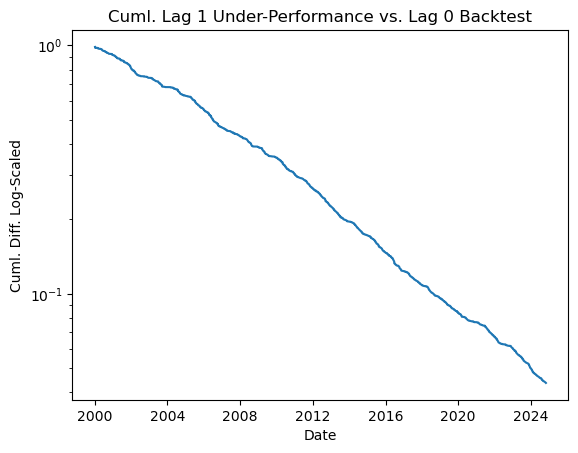

In [17]:
(df_spread
    [["spread2"]]
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        logy   = True,
        legend = False,
        ylabel = "Cuml. Diff. Log-Scaled",
        title  = "Cuml. Lag 1 Under-Performance vs. Lag 0 Backtest",
        xlabel = "Date"))

plt.show()

In [27]:
df_cl = (df_signal
    .loc[lambda x: x.ticker == "cl1_comdty"]
    .set_index("date")
    [["px"]])

<Axes: xlabel='signal_a', ylabel='signal_b'>

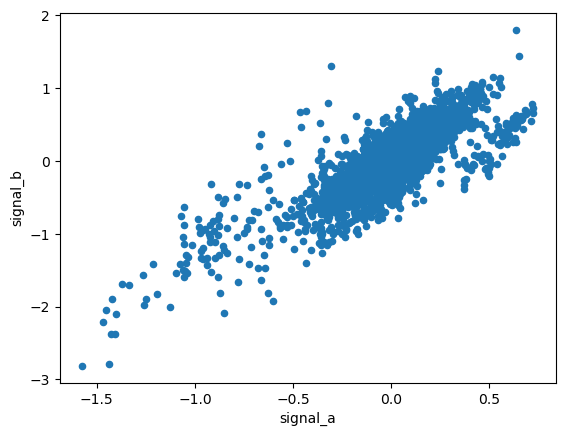

In [37]:
(df_cl
    .assign(
        fast_window_a = lambda x: x.px.ewm(span = 65, adjust = False).mean(),
        slow_window_a = lambda x: x.px.ewm(span = 130, adjust = False).mean(),
        signal_a    = lambda x: x.fast_window_a - x.slow_window_a,
        fast_window_b = lambda x: x.px.ewm(span = 16, adjust = False).mean(),
        slow_window_b = lambda x: x.px.ewm(span = 64, adjust = False).mean(),
        ewmac_fast    = lambda x: x.fast_window_b - x.slow_window_b,
        fast1_b       = lambda x: x.px.ewm(span = 128, adjust = False).mean(),
        slow1_b       = lambda x: x.px.ewm(span = 512, adjust = False).mean(),
        ewmac_slow    = lambda x: x.fast1_b - x.slow1_b,
        signal_b      = lambda x: (0.5 * x.ewmac_fast) + (0.5 * x.ewmac_slow))
    [["signal_a", "signal_b"]]
    .diff()
    .plot(kind = "scatter", x = "signal_a", y = "signal_b"))